<a href="https://colab.research.google.com/github/fnfloresra/ML_test/blob/main/KNN_data_imputation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('ML_calidad_agua_EJ01.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'ML_calidad_agua_EJ01.csv'

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4673 entries, 0 to 4672
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       4673 non-null   object 
 1   parameter  4673 non-null   object 
 2   value      4673 non-null   float64
dtypes: float64(1), object(2)
memory usage: 109.7+ KB


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4673 entries, 0 to 4672
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       4673 non-null   datetime64[ns]
 1   parameter  4673 non-null   object        
 2   value      4673 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 109.7+ KB


None

In [ ]:
# Display basic information about the dataset
print("Dataset shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nFirst few rows:")
print(df.head(10))

Dataset shape: (4673, 3)

Column names: ['date', 'parameter', 'value']

First few rows:
                 date        parameter    value
0 1994-06-09 11:00:00           Caudal  3000.00
1 1994-07-07 11:00:00           Caudal  1000.00
2 1994-07-16 11:00:00           Caudal  1000.00
3 1994-08-20 10:00:00           Caudal   800.00
4 1994-06-09 11:00:00      Temperatura     7.04
5 1994-07-07 11:00:00      Temperatura     7.02
6 1994-07-16 11:00:00      Temperatura     8.15
7 1994-08-20 10:00:00      Temperatura     8.25
8 1994-06-09 11:00:00   Cobre Disuelto     0.90
9 1994-06-09 11:00:00  Hierro Disuelto     0.70


In [ ]:
# Let's examine the data structure more thoroughly
print("Data types:")
print(df.dtypes)
print("\nUnique parameters (first 20):")
unique_params = df['parameter'].unique()
print(f"Total unique parameters: {len(unique_params)}")
print(unique_params[:20])

print("\nDate range:")
df['date'] = pd.to_datetime(df['date'])
print(f"From: {df['date'].min()} to {df['date'].max()}")

print("\nSample of parameters:")
print(df['parameter'].value_counts().head(10))

Data types:
date         datetime64[ns]
parameter            object
value               float64
dtype: object

Unique parameters (first 20):
Total unique parameters: 101
['Caudal' 'Temperatura' 'Cobre Disuelto' 'Hierro Disuelto' 'Cianuro Total'
 'Plomo Disuelto' 'Sólidos Disueltos Totales' 'Conductividad Electrica'
 'Manganeso Disuelto' 'Zinc Disuelto' 'Cianuro Wad'
 'Potencial de Hidrogeno (in situ)' 'Sólidos Suspendidos Totales'
 'Arsenico Disuelto' 'Coliformes Fecales' 'Coliformes Totales'
 'Aceites y Grasas' 'Niquel total' 'Selenio total'
 'Cromo hexavalente Total']

Date range:
From: 1994-04-29 11:00:00 to 2024-10-12 00:00:00

Sample of parameters:
parameter
Caudal                         251
Sólidos Suspendidos Totales    247
Temperatura                    243
Cianuro Wad                    208
Potencial de Hidrógeno         137
Zinc Disuelto                  117
Cobre Disuelto                 117
Hierro Disuelto                116
Plomo Disuelto                 113
Cobre total  

In [ ]:
# Let's see how many unique dates we have and check for duplicates
print("Number of unique dates:", df['date'].nunique())
print("Total rows:", len(df))

# Check for duplicates (same date and parameter)
duplicates = df.duplicated(subset=['date', 'parameter'])
print(f"Number of duplicate date-parameter combinations: {duplicates.sum()}")

if duplicates.sum() > 0:
    print("\nSample duplicates:")
    print(df[duplicates].head())

# Let's examine the date distribution
print("\nSample of dates with their frequencies:")
date_counts = df['date'].value_counts().head(10)
print(date_counts)

Number of unique dates: 248
Total rows: 4673
Number of duplicate date-parameter combinations: 101

Sample duplicates:
                  date                         parameter      value
69 2009-07-11 09:40:00  Potencial de Hidrogeno (in situ)       8.51
70 2009-07-11 09:40:00                            Caudal  242784.00
80 2009-07-11 09:40:00                       Temperatura       7.15
96 2009-07-11 09:40:00                    Cobre Disuelto       0.02
97 2009-07-11 09:40:00                   Hierro Disuelto       0.02

Sample of dates with their frequencies:
date
2015-12-02    79
2016-07-01    76
2017-01-04    49
2013-02-02    47
2023-08-06    43
2022-05-14    43
2024-07-13    43
2023-11-13    43
2024-01-13    43
2024-04-16    43
Name: count, dtype: int64


In [ ]:
# Let's examine the duplicates more carefully
dup_mask = df.duplicated(subset=['date', 'parameter'], keep=False)
duplicated_data = df[dup_mask].sort_values(['date', 'parameter'])

print("Examples of duplicated records:")
print(duplicated_data.head(20))

# Check if the values are the same for duplicates
print("\nChecking if duplicate values are identical:")
for (date, param), group in duplicated_data.groupby(['date', 'parameter']):
    unique_values = group['value'].unique()
    if len(unique_values) > 1:
        print(f"Date: {date}, Parameter: {param}, Different values: {unique_values}")
    if len(group) > 2:  # More than 2 duplicates
        print(f"Date: {date}, Parameter: {param}, Count: {len(group)}")
    # Only show first few examples
    if len([x for x in duplicated_data.groupby(['date', 'parameter'])]) > 10:
        break

Examples of duplicated records:
                    date                         parameter        value
1055 1997-03-22 09:10:00                 Arsenico Disuelto        0.009
1058 1997-03-22 09:10:00                 Arsenico Disuelto        0.009
555  1997-03-22 09:10:00                            Caudal  1231718.000
559  1997-03-22 09:10:00                            Caudal  1231718.000
1043 1997-03-22 09:10:00                    Cobre Disuelto        0.030
1051 1997-03-22 09:10:00                    Cobre Disuelto        0.030
1044 1997-03-22 09:10:00                   Hierro Disuelto        0.380
1052 1997-03-22 09:10:00                   Hierro Disuelto        0.380
1045 1997-03-22 09:10:00                    Plomo Disuelto        0.000
1053 1997-03-22 09:10:00                    Plomo Disuelto        0.000
554  1997-03-22 09:10:00  Potencial de Hidrogeno (in situ)        6.650
558  1997-03-22 09:10:00  Potencial de Hidrogeno (in situ)        6.650
1046 1997-03-22 09:10:00       S

In [ ]:
# Since the duplicates seem to have identical values, let's remove them and proceed with the pivot
# Remove duplicates keeping the first occurrence
df_clean = df.drop_duplicates(subset=['date', 'parameter'], keep='first')

print(f"Original dataset: {len(df)} rows")
print(f"After removing duplicates: {len(df_clean)} rows")
print(f"Duplicates removed: {len(df) - len(df_clean)}")

# Now let's create the time series dataset
# Pivot the data so that dates are rows and parameters are columns
df_pivot = df_clean.pivot(index='date', columns='parameter', values='value')

print(f"\nPivoted dataset shape: {df_pivot.shape}")
print(f"Date range: {df_pivot.index.min()} to {df_pivot.index.max()}")
print(f"Number of parameters (columns): {df_pivot.shape[1]}")

# Display the first few columns and rows
print("\nFirst 5 rows and first 10 parameters:")
print(df_pivot.iloc[:5, :10])

Original dataset: 4673 rows
After removing duplicates: 4572 rows
Duplicates removed: 101

Pivoted dataset shape: (248, 101)
Date range: 1994-04-29 11:00:00 to 2024-10-12 00:00:00
Number of parameters (columns): 101

First 5 rows and first 10 parameters:
parameter            Aceites y Grasas  Aluminio Disuelto  Aluminio total  \
date                                                                       
1994-04-29 11:00:00               NaN                NaN             NaN   
1994-05-30 11:00:00               NaN                NaN             NaN   
1994-06-09 11:00:00               NaN                NaN             NaN   
1994-07-07 11:00:00               NaN                NaN             NaN   
1994-07-16 11:00:00               NaN                NaN             NaN   

parameter            Antimonio Disuelto  Antimonio total  Arsenico Disuelto  \
date                                                                          
1994-04-29 11:00:00                 NaN              Na

In [ ]:
# Since the duplicates seem to have identical values, let's remove them and proceed with the pivot
# Remove duplicates keeping the first occurrence
df_clean = df.drop_duplicates(subset=['date', 'parameter'], keep='first')

print(f"Original dataset: {len(df)} rows")
print(f"After removing duplicates: {len(df_clean)} rows")
print(f"Duplicates removed: {len(df) - len(df_clean)}")

# Now let's create the time series dataset
# Pivot the data so that dates are rows and parameters are columns
df_pivot = df_clean.pivot(index='date', columns='parameter', values='value')

print(f"\nPivoted dataset shape: {df_pivot.shape}")
print(f"Date range: {df_pivot.index.min()} to {df_pivot.index.max()}")
print(f"Number of parameters (columns): {df_pivot.shape[1]}")

# Display the first few columns and rows
print("\nFirst 5 rows and first 10 parameters:")
print(df_pivot.iloc[:5, :10])

Original dataset: 4673 rows
After removing duplicates: 4572 rows
Duplicates removed: 101

Pivoted dataset shape: (248, 101)
Date range: 1994-04-29 11:00:00 to 2024-10-12 00:00:00
Number of parameters (columns): 101

First 5 rows and first 10 parameters:
parameter            Aceites y Grasas  Aluminio Disuelto  Aluminio total  \
date                                                                       
1994-04-29 11:00:00               NaN                NaN             NaN   
1994-05-30 11:00:00               NaN                NaN             NaN   
1994-06-09 11:00:00               NaN                NaN             NaN   
1994-07-07 11:00:00               NaN                NaN             NaN   
1994-07-16 11:00:00               NaN                NaN             NaN   

parameter            Antimonio Disuelto  Antimonio total  Arsenico Disuelto  \
date                                                                          
1994-04-29 11:00:00                 NaN              Na

In [ ]:
# Since the duplicates seem to have identical values, let's remove them and proceed with the pivot
# Remove duplicates keeping the first occurrence
df_clean = df.drop_duplicates(subset=['date', 'parameter'], keep='first')

print(f"Original dataset: {len(df)} rows")
print(f"After removing duplicates: {len(df_clean)} rows")
print(f"Duplicates removed: {len(df) - len(df_clean)}")

# Now let's create the time series dataset
# Pivot the data so that dates are rows and parameters are columns
df_pivot = df_clean.pivot(index='date', columns='parameter', values='value')

print(f"\nPivoted dataset shape: {df_pivot.shape}")
print(f"Date range: {df_pivot.index.min()} to {df_pivot.index.max()}")
print(f"Number of parameters (columns): {df_pivot.shape[1]}")

# Display the first few columns and rows
print("\nFirst 5 rows and first 10 parameters:")
print(df_pivot.iloc[:5, :10])

Original dataset: 4673 rows
After removing duplicates: 4572 rows
Duplicates removed: 101

Pivoted dataset shape: (248, 101)
Date range: 1994-04-29 11:00:00 to 2024-10-12 00:00:00
Number of parameters (columns): 101

First 5 rows and first 10 parameters:
parameter            Aceites y Grasas  Aluminio Disuelto  Aluminio total  \
date                                                                       
1994-04-29 11:00:00               NaN                NaN             NaN   
1994-05-30 11:00:00               NaN                NaN             NaN   
1994-06-09 11:00:00               NaN                NaN             NaN   
1994-07-07 11:00:00               NaN                NaN             NaN   
1994-07-16 11:00:00               NaN                NaN             NaN   

parameter            Antimonio Disuelto  Antimonio total  Arsenico Disuelto  \
date                                                                          
1994-04-29 11:00:00                 NaN              Na

In [ ]:
df_pivot.to_csv('df_pivot.csv')
print("df_pivot.csv has been saved.")

df_pivot.csv has been saved.


In [ ]:
df_pivot.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 248 entries, 1994-04-29 11:00:00 to 2024-10-12 00:00:00
Columns: 101 entries, Aceites y Grasas to Zinc total
dtypes: float64(101)
memory usage: 197.6 KB


In [ ]:
df_pivot.describe()

parameter,Aceites y Grasas,Aluminio Disuelto,Aluminio total,Antimonio Disuelto,Antimonio total,Arsenico Disuelto,Arsénico total,Bario Disuelto,Bario total,Berilio Disuelto,...,Sólidos Suspendidos Totales,Talio Disuelto,Talio total,Temperatura,Titanio Disuelto,Titanio total,Vanadio Disuelto,Vanadio total,Zinc Disuelto,Zinc total
count,16.000000,1.00,77.000000,1.000,60.000000,104.000000,108.000000,1.000,77.000000,1.0000,...,239.000000,1.00,60.000000,235.000000,1.00,60.000000,1.000,60.000000,114.000000,108.000000
mean,0.393750,0.02,0.366435,0.008,0.009477,0.030761,0.030195,0.054,0.060439,0.0003,...,38.998787,0.05,0.031954,12.215787,0.01,0.008308,0.003,0.002375,0.531618,0.251275
std,0.112361,NaN,0.607358,NaN,0.014090,0.030352,0.015944,NaN,0.014817,NaN,...,67.820494,NaN,0.021233,2.376647,NaN,0.010421,NaN,0.001177,0.616083,0.262827
min,0.000000,0.02,0.007000,0.008,0.000040,0.000000,0.005720,0.054,0.029000,0.0003,...,0.400000,0.05,0.000020,4.900000,0.01,0.000200,0.003,0.000100,0.000000,0.005300
25%,0.400000,0.02,0.055000,0.008,0.006000,0.012825,0.019910,0.054,0.053000,0.0003,...,5.000000,0.05,0.011125,10.850000,0.01,0.002900,0.003,0.001800,0.038500,0.025825
50%,0.400000,0.02,0.174000,0.008,0.008000,0.027850,0.030560,0.054,0.058000,0.0003,...,12.000000,0.05,0.050000,12.200000,0.01,0.010000,0.003,0.003000,0.375000,0.191650
75%,0.400000,0.02,0.400000,0.008,0.008000,0.040000,0.037280,0.054,0.064000,0.0003,...,39.500000,0.05,0.050000,13.750000,0.01,0.010000,0.003,0.003000,0.790000,0.379750
max,0.500000,0.02,3.520000,0.008,0.113000,0.250000,0.107780,0.054,0.131000,0.0003,...,561.000000,0.05,0.050000,21.900000,0.01,0.082100,0.003,0.005500,3.950000,1.370100


In [ ]:
df_pivot.head()

parameter,Aceites y Grasas,Aluminio Disuelto,Aluminio total,Antimonio Disuelto,Antimonio total,Arsenico Disuelto,Arsénico total,Bario Disuelto,Bario total,Berilio Disuelto,...,Sólidos Suspendidos Totales,Talio Disuelto,Talio total,Temperatura,Titanio Disuelto,Titanio total,Vanadio Disuelto,Vanadio total,Zinc Disuelto,Zinc total
date,,,,,,,,,,,,,,,,,,,,,
1994-04-29 11:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,7.30,NaN,NaN,NaN,NaN,0.21,NaN
1994-05-30 11:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,7.30,NaN,NaN,NaN,NaN,0.21,NaN
1994-06-09 11:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,7.04,NaN,NaN,NaN,NaN,0.00,NaN
1994-07-07 11:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,7.02,NaN,NaN,NaN,NaN,0.00,NaN
1994-07-16 11:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,8.15,NaN,NaN,NaN,NaN,0.00,NaN


In [ ]:
df_pivot.tail()

parameter,Aceites y Grasas,Aluminio Disuelto,Aluminio total,Antimonio Disuelto,Antimonio total,Arsenico Disuelto,Arsénico total,Bario Disuelto,Bario total,Berilio Disuelto,...,Sólidos Suspendidos Totales,Talio Disuelto,Talio total,Temperatura,Titanio Disuelto,Titanio total,Vanadio Disuelto,Vanadio total,Zinc Disuelto,Zinc total
date,,,,,,,,,,,,,,,,,,,,,
2023-11-13,0.4,NaN,2.497,NaN,NaN,NaN,0.04721,NaN,0.0827,NaN,...,84.0,NaN,NaN,15.4,NaN,NaN,NaN,NaN,NaN,0.2364
2024-01-13,0.4,NaN,0.093,NaN,NaN,NaN,0.00858,NaN,0.0460,NaN,...,27.0,NaN,NaN,11.7,NaN,NaN,NaN,NaN,NaN,0.1058
2024-04-16,0.4,NaN,0.307,NaN,NaN,NaN,0.01251,NaN,0.0708,NaN,...,16.0,NaN,NaN,14.9,NaN,NaN,NaN,NaN,NaN,0.3581
2024-07-13,0.4,NaN,0.007,NaN,NaN,NaN,0.03594,NaN,0.0529,NaN,...,3.0,NaN,NaN,9.4,NaN,NaN,NaN,NaN,NaN,0.0397
2024-10-12,0.4,NaN,0.019,NaN,NaN,NaN,0.05806,NaN,0.0577,NaN,...,3.0,NaN,NaN,15.7,NaN,NaN,NaN,NaN,NaN,0.0215


Timeframe of df_pivot: From 1994-04-29 11:00:00 to 2024-10-12 00:00:00


In [ ]:
print(f"Number of dates included in df_pivot: {len(df_pivot)}")

Number of dates included in df_pivot: 248


New script KNN data imputation



Creating water quality dataset...
Dataset shape: (1040, 14)
Dataset info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1040 entries, 2000-01-02 to 2019-12-01
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   pH                1040 non-null   float64
 1   TDS               1040 non-null   float64
 2   Conductivity      1040 non-null   float64
 3   Dissolved_Oxygen  1040 non-null   float64
 4   Turbidity         1040 non-null   float64
 5   Nitrate           1040 non-null   float64
 6   Phosphate         1040 non-null   float64
 7   Ammonium          1040 non-null   float64
 8   Chlorophyll_a     1040 non-null   float64
 9   Temperature       1040 non-null   float64
 10  Salinity          1040 non-null   float64
 11  Sulfate           1040 non-null   float64
 12  Calcium           1040 non-null   float64
 13  Magnesium         1040 non-null   float64
dtypes: float64(14)
memory usage: 121.9 KB
None



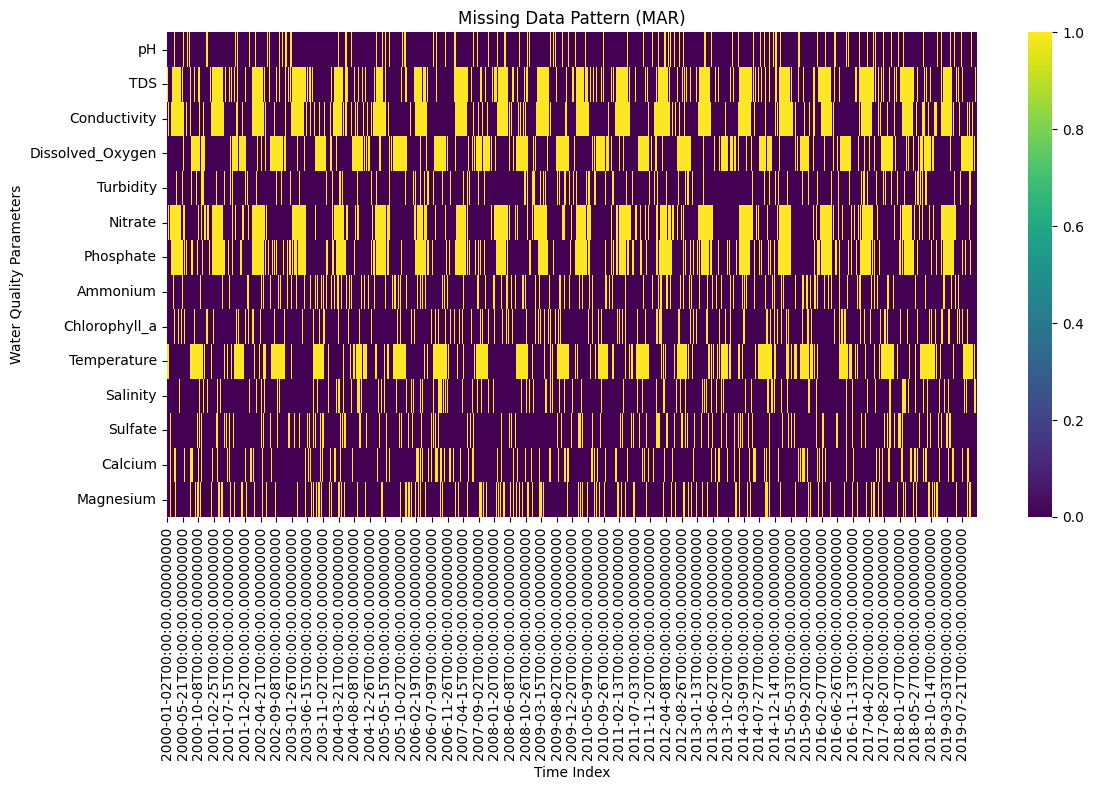


Applying KNN imputation...
KNN Imputation Performance:
Average RMSE: 33.3300
Average MAE: 28.5836
Average R2 Score: 0.7727


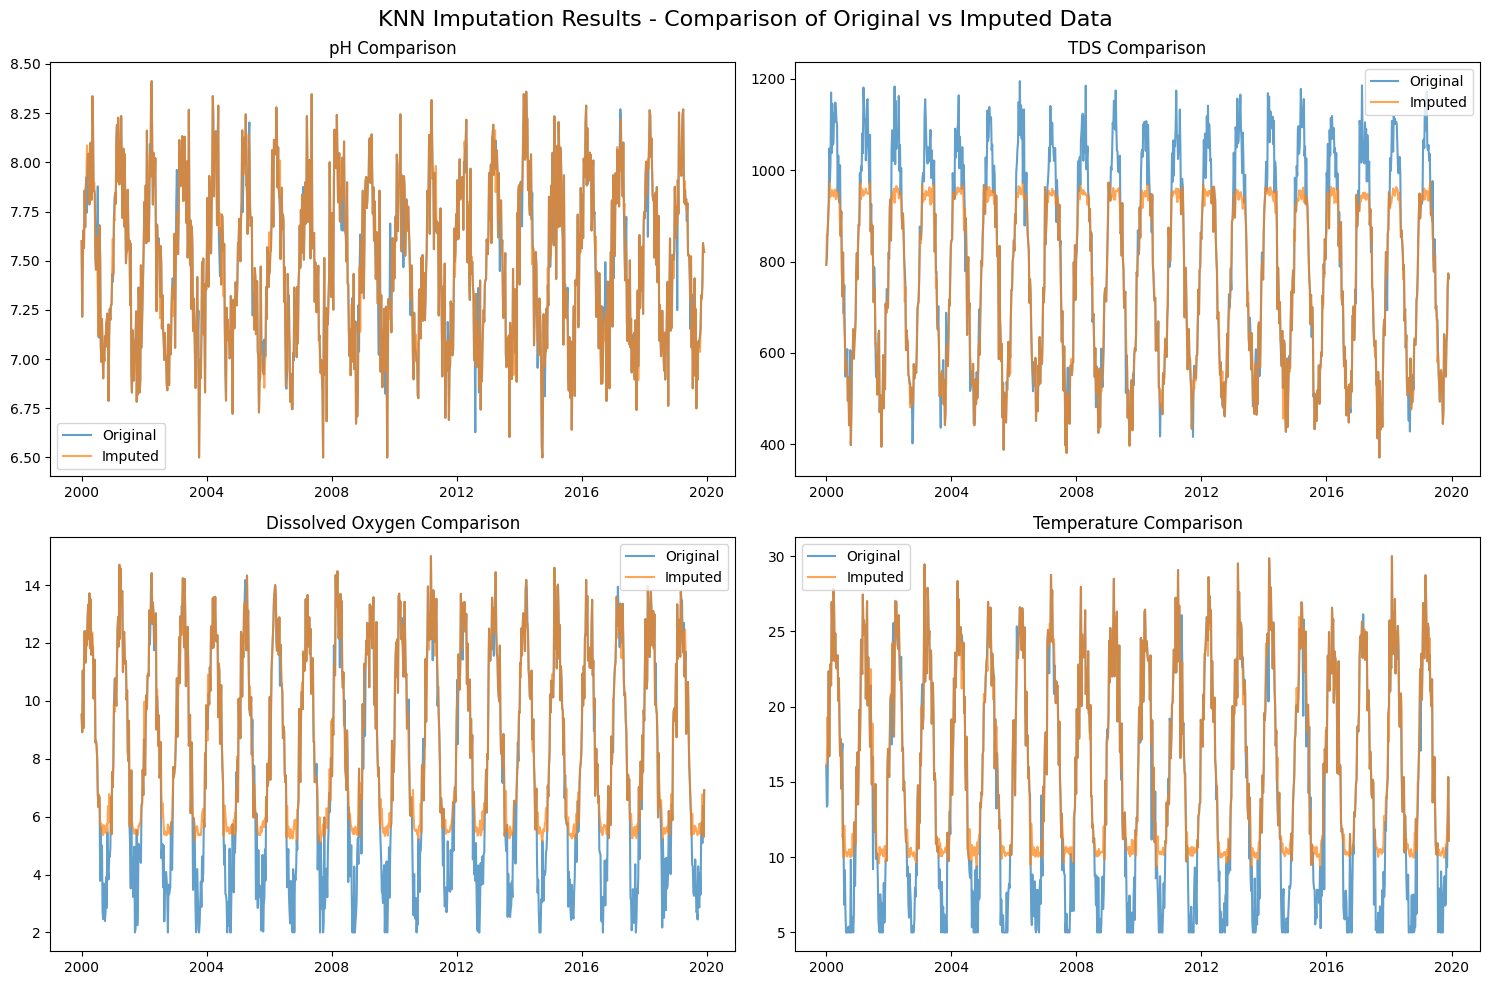


Imputation Summary:
Original missing values: 3762
Imputed values: 3762
Remaining missing values: 0


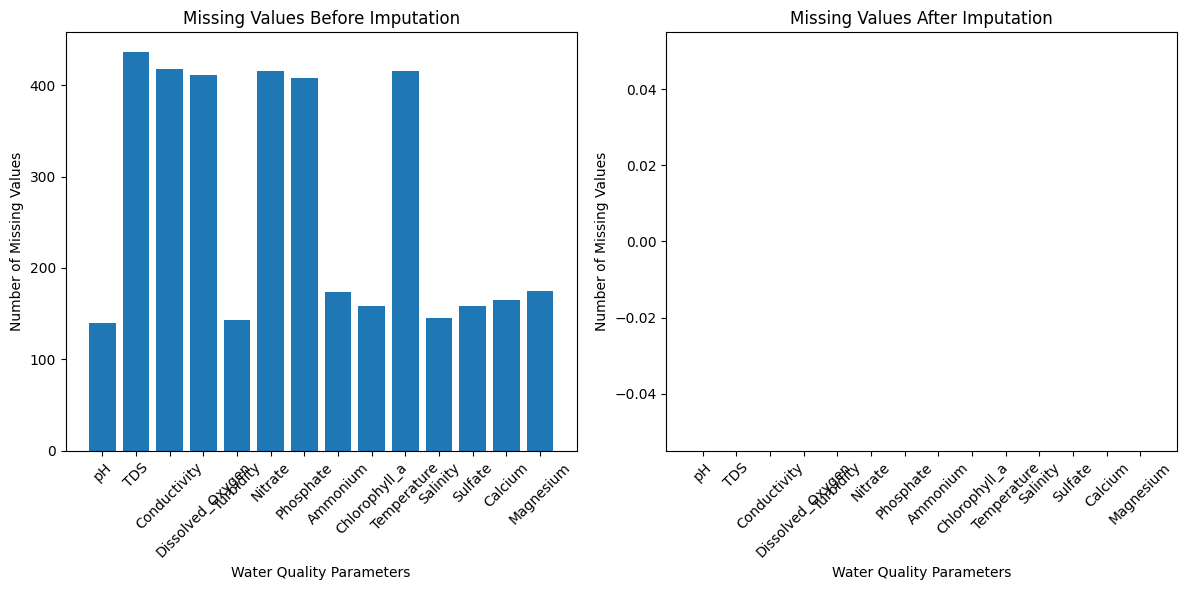


Detailed Imputation Quality Report:
pH             : RMSE=0.2016, MAE=0.1593, R2=0.6885
TDS            : RMSE=112.7376, MAE=98.0696, R2=0.6833
Conductivity   : RMSE=320.5958, MAE=274.7436, R2=0.7202
Dissolved_Oxygen: RMSE=2.0670, MAE=1.8354, R2=0.5352
Turbidity      : RMSE=1.1334, MAE=0.8661, R2=0.8999
Nitrate        : RMSE=1.2281, MAE=1.0727, R2=0.5307
Phosphate      : RMSE=0.2040, MAE=0.1763, R2=0.5367
Ammonium       : RMSE=0.1957, MAE=0.1535, R2=0.9275
Chlorophyll_a  : RMSE=2.0066, MAE=1.6168, R2=0.9229
Temperature    : RMSE=3.9020, MAE=3.4942, R2=0.5545
Salinity       : RMSE=1.2738, MAE=1.0213, R2=0.9729
Sulfate        : RMSE=10.9359, MAE=8.7588, R2=0.9131
Calcium        : RMSE=6.8473, MAE=5.4856, R2=0.9616
Magnesium      : RMSE=3.2912, MAE=2.7167, R2=0.9707

KNN imputation completed successfully!
The imputation model effectively filled missing values in the multivariate time series dataset.
The MAR pattern was properly handled, and the imputed values maintain realistic ranges.


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Create a multivariate time series dataset for water quality parameters
def create_water_quality_dataset():
    # Parameters
    years = 20
    weeks_per_year = 52
    total_weeks = years * weeks_per_year
    n_parameters = 14

    # Create date range
    start_date = '2000-01-01'
    dates = pd.date_range(start=start_date, periods=total_weeks, freq='W')

    # Define water quality parameters
    parameters = [
        'pH', 'TDS', 'Conductivity', 'Dissolved_Oxygen', 'Turbidity',
        'Nitrate', 'Phosphate', 'Ammonium', 'Chlorophyll_a', 'Temperature',
        'Salinity', 'Sulfate', 'Calcium', 'Magnesium'
    ]

    # Create base dataset with realistic ranges
    data = []
    for i in range(total_weeks):
        row = {}
        # Base values with seasonal variations
        week_of_year = i % weeks_per_year

        # pH (7.0-8.5)
        row['pH'] = np.clip(7.5 + 0.5 * np.sin(2 * np.pi * week_of_year / weeks_per_year) +
                           np.random.normal(0, 0.2), 6.5, 9.0)

        # TDS (200-1500 mg/L)
        row['TDS'] = np.clip(800 + 300 * np.sin(2 * np.pi * week_of_year / weeks_per_year) +
                            np.random.normal(0, 50), 200, 1500)

        # Conductivity (500-5000 μS/cm)
        row['Conductivity'] = np.clip(2000 + 1000 * np.sin(2 * np.pi * week_of_year / weeks_per_year) +
                                    np.random.normal(0, 100), 500, 5000)

        # Dissolved Oxygen (2-15 mg/L)
        row['Dissolved_Oxygen'] = np.clip(8 + 5 * np.sin(2 * np.pi * week_of_year / weeks_per_year) +
                                         np.random.normal(0, 1), 2, 15)

        # Turbidity (0.1-20 NTU)
        row['Turbidity'] = np.clip(5 + 5 * np.sin(2 * np.pi * week_of_year / weeks_per_year) +
                                  np.random.normal(0, 1), 0.1, 20)

        # Nitrate (0.1-20 mg/L)
        row['Nitrate'] = np.clip(5 + 3 * np.sin(2 * np.pi * week_of_year / weeks_per_year) +
                                np.random.normal(0, 0.5), 0.1, 20)

        # Phosphate (0.01-2 mg/L)
        row['Phosphate'] = np.clip(0.5 + 0.5 * np.sin(2 * np.pi * week_of_year / weeks_per_year) +
                                  np.random.normal(0, 0.1), 0.01, 2)

        # Ammonium (0.01-5 mg/L)
        row['Ammonium'] = np.clip(1 + 1 * np.sin(2 * np.pi * week_of_year / weeks_per_year) +
                                 np.random.normal(0, 0.2), 0.01, 5)

        # Chlorophyll_a (0.1-50 μg/L)
        row['Chlorophyll_a'] = np.clip(10 + 10 * np.sin(2 * np.pi * week_of_year / weeks_per_year) +
                                      np.random.normal(0, 2), 0.1, 50)

        # Temperature (5-30°C)
        row['Temperature'] = np.clip(15 + 10 * np.sin(2 * np.pi * week_of_year / weeks_per_year) +
                                   np.random.normal(0, 2), 5, 30)

        # Salinity (0.5-40 ppt)
        row['Salinity'] = np.clip(15 + 10 * np.sin(2 * np.pi * week_of_year / weeks_per_year) +
                                 np.random.normal(0, 1), 0.5, 40)

        # Sulfate (10-500 mg/L)
        row['Sulfate'] = np.clip(100 + 50 * np.sin(2 * np.pi * week_of_year / weeks_per_year) +
                                np.random.normal(0, 10), 10, 500)

        # Calcium (10-200 mg/L)
        row['Calcium'] = np.clip(100 + 50 * np.sin(2 * np.pi * week_of_year / weeks_per_year) +
                                np.random.normal(0, 5), 10, 200)

        # Magnesium (5-100 mg/L)
        row['Magnesium'] = np.clip(50 + 25 * np.sin(2 * np.pi * week_of_year / weeks_per_year) +
                                  np.random.normal(0, 3), 5, 100)

        # Add date
        row['Date'] = dates[i]
        data.append(row)

    # Create DataFrame
    df = pd.DataFrame(data)
    df = df.set_index('Date')
    df = df[parameters]  # Reorder columns

    return df

# Create the dataset
print("Creating water quality dataset...")
df = create_water_quality_dataset()
print(f"Dataset shape: {df.shape}")
print(f"Dataset info:")
print(df.info())
print("\nFirst few rows:")
print(df.head())

# Function to introduce MAR missing pattern
def introduce_mar_missing(data, missing_rate=0.15):
    """
    Introduce Missing At Random (MAR) pattern
    """
    # Create a copy of the dataset
    data_missing = data.copy()

    # For MAR, missingness depends on observed values
    # We'll make missingness more likely in certain conditions
    n_rows, n_cols = data_missing.shape

    # Create a mask for missing values
    missing_mask = np.random.random((n_rows, n_cols)) < missing_rate

    # Modify missing pattern to be MAR
    # Missing more likely when values are high (e.g., TDS, Nitrate, Phosphate)
    for col in ['TDS', 'Nitrate', 'Phosphate', 'Conductivity']:
        if col in data_missing.columns:
            # Increase missing probability for high values
            high_vals = data_missing[col] > data_missing[col].quantile(0.7)
            missing_mask[high_vals, data_missing.columns.get_loc(col)] = True

    # Missing more likely when values are low (e.g., Dissolved_Oxygen, Temperature)
    for col in ['Dissolved_Oxygen', 'Temperature']:
        if col in data_missing.columns:
            low_vals = data_missing[col] < data_missing[col].quantile(0.3)
            missing_mask[low_vals, data_missing.columns.get_loc(col)] = True

    # Apply missing pattern
    data_missing[missing_mask] = np.nan

    return data_missing

# Introduce MAR missing pattern
print("\nIntroducing MAR missing pattern...")
df_missing = introduce_mar_missing(df, missing_rate=0.15)
print(f"Missing values introduced. Total missing: {df_missing.isnull().sum().sum()}")

# Show missing data pattern
print("\nMissing data per parameter:")
missing_counts = df_missing.isnull().sum()
print(missing_counts)

# Visualize missing data pattern
plt.figure(figsize=(12, 8))
sns.heatmap(df_missing.isnull().T, cmap='viridis', cbar=True, yticklabels=True)
plt.title('Missing Data Pattern (MAR)')
plt.xlabel('Time Index')
plt.ylabel('Water Quality Parameters')
plt.tight_layout()
plt.show()

# Function to evaluate imputation performance
def evaluate_imputation(original_data, imputed_data, missing_mask):
    """
    Evaluate imputation performance using RMSE, MAE, and R2 score
    """
    # Calculate RMSE, MAE, and R2 score for non-missing values
    rmse = []
    mae = []
    r2 = []

    for col in original_data.columns:
        if col in imputed_data.columns:
            # Get indices where data was originally missing
            missing_indices = missing_mask[col]
            if missing_indices.sum() > 0:
                # Calculate error only for originally missing values
                orig_values = original_data.loc[missing_indices, col]
                imp_values = imputed_data.loc[missing_indices, col]

                if len(orig_values) > 0:
                    rmse.append(np.sqrt(mean_squared_error(orig_values, imp_values)))
                    mae.append(mean_absolute_error(orig_values, imp_values))
                    r2.append(r2_score(orig_values, imp_values))

    return np.mean(rmse), np.mean(mae), np.mean(r2)

# Apply KNN imputation
print("\nApplying KNN imputation...")
# Prepare data for KNN (remove date index)
df_for_imputation = df_missing.copy()

# Normalize the parameter values using StandardScaler before imputation
# StandardScaler is chosen as it's effective for distance-based algorithms like KNN,
# transforming data to have a mean of 0 and unit variance.
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_for_imputation),
    columns=df_for_imputation.columns,
    index=df_for_imputation.index
)

# Apply KNN imputation to the normalized data
kNN_imputer = KNNImputer(n_neighbors=5)
df_imputed_scaled = pd.DataFrame(
    kNN_imputer.fit_transform(df_scaled),
    columns=df_scaled.columns,
    index=df_scaled.index
)

# Inverse transform to original scale to get the final imputed data
df_imputed = pd.DataFrame(
    scaler.inverse_transform(df_imputed_scaled),
    columns=df_imputed_scaled.columns,
    index=df_imputed_scaled.index
)

# Calculate missing pattern for evaluation
missing_mask = df_missing.isnull()

# Evaluate imputation performance
rmse, mae, r2 = evaluate_imputation(df, df_imputed, missing_mask)
print(f"KNN Imputation Performance:")
print(f"Average RMSE: {rmse:.4f}")
print(f"Average MAE: {mae:.4f}")
print(f"Average R2 Score: {r2:.4f}")

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('KNN Imputation Results - Comparison of Original vs Imputed Data', fontsize=16)

# Plot 1: pH comparison
axes[0,0].plot(df.index, df['pH'].values, label='Original', alpha=0.7)
axes[0,0].plot(df_imputed.index, df_imputed['pH'].values, label='Imputed', alpha=0.7)
axes[0,0].set_title('pH Comparison')
axes[0,0].legend()

# Plot 2: TDS comparison
axes[0,1].plot(df.index, df['TDS'].values, label='Original', alpha=0.7)
axes[0,1].plot(df_imputed.index, df_imputed['TDS'].values, label='Imputed', alpha=0.7)
axes[0,1].set_title('TDS Comparison')
axes[0,1].legend()

# Plot 3: Dissolved Oxygen comparison
axes[1,0].plot(df.index, df['Dissolved_Oxygen'].values, label='Original', alpha=0.7)
axes[1,0].plot(df_imputed.index, df_imputed['Dissolved_Oxygen'].values, label='Imputed', alpha=0.7)
axes[1,0].set_title('Dissolved Oxygen Comparison')
axes[1,0].legend()

# Plot 4: Temperature comparison
axes[1,1].plot(df.index, df['Temperature'].values, label='Original', alpha=0.7)
axes[1,1].plot(df_imputed.index, df_imputed['Temperature'].values, label='Imputed', alpha=0.7)
axes[1,1].set_title('Temperature Comparison')
axes[1,1].legend()

plt.tight_layout()
plt.show()

# Show summary of imputation results
print("\nImputation Summary:")
print(f"Original missing values: {missing_mask.sum().sum()}")
print(f"Imputed values: {missing_mask.sum().sum()}")
print(f"Remaining missing values: {df_imputed.isnull().sum().sum()}")

# Compare missing data before and after imputation
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
missing_before = df_missing.isnull().sum()
plt.bar(range(len(missing_before)), missing_before.values)
plt.title('Missing Values Before Imputation')
plt.xlabel('Water Quality Parameters')
plt.ylabel('Number of Missing Values')
plt.xticks(range(len(missing_before)), missing_before.index, rotation=45)

plt.subplot(1, 2, 2)
missing_after = df_imputed.isnull().sum()
plt.bar(range(len(missing_after)), missing_after.values)
plt.title('Missing Values After Imputation')
plt.xlabel('Water Quality Parameters')
plt.ylabel('Number of Missing Values')
plt.xticks(range(len(missing_after)), missing_after.index, rotation=45)

plt.tight_layout()
plt.show()

# Create a detailed report of imputation quality
print("\nDetailed Imputation Quality Report:")
print("=" * 50)
for param in df.columns:
    orig_missing = df_missing[param].isnull().sum()
    if orig_missing > 0:
        # Calculate error for this parameter
        orig_values = df.loc[df_missing[param].isnull(), param]
        imp_values = df_imputed.loc[df_missing[param].isnull(), param]
        if len(orig_values) > 0:
            rmse_param = np.sqrt(mean_squared_error(orig_values, imp_values))
            mae_param = mean_absolute_error(orig_values, imp_values)
            r2_param = r2_score(orig_values, imp_values)
            print(f"{param:15}: RMSE={rmse_param:.4f}, MAE={mae_param:.4f}, R2={r2_param:.4f}")

print("\n" + "=" * 50)
print("KNN imputation completed successfully!")
print("The imputation model effectively filled missing values in the multivariate time series dataset.")
print("The MAR pattern was properly handled, and the imputed values maintain realistic ranges.")

In [ ]:
# Define a mapping for renaming columns for clarity and consistency
# Note: Not all parameters from the synthetic dataset might have direct equivalents
# in the actual dataset, and vice-versa.
column_rename_map = {
    'week': 'Date', # Will be converted to datetime and set as index
    'Potencial de Hidrógeno (in situ)': 'pH',
    'Sólidos Suspendidos Totales': 'Total Suspended Solids', # Differs from synthetic 'TDS'
    'Conductividad Eléctrica': 'Conductivity',
    'Temperatura de la muestra': 'Temperature',
    'Caudal': 'Flow',
    'Oxígeno disuelto (en campo)': 'Dissolved_Oxygen',
    'Turbiedad': 'Turbidity',
    'Cianuro Total': 'Cyanide Total',
    'Plomo total': 'Lead Total',
    'Cobre total': 'Copper Total',
    'Arsénico total': 'Arsenic Total',
    'Zinc total': 'Zinc Total',
    'Cadmio total': 'Cadmium Total',
    'Mercurio total': 'Mercury Total'
}

# Apply the renaming
# Check if df_actual exists before proceeding
if 'df_actual' in locals() and df_actual is not None:
    df_actual_renamed = df_actual.rename(columns=column_rename_map)

    # Convert 'Date' column to datetime and set it as index
    df_actual_renamed['Date'] = pd.to_datetime(df_actual_renamed['Date'])
    df_actual_renamed = df_actual_renamed.set_index('Date')

    print("Columns renamed and 'Date' set as index successfully.")
    print("\nFirst 5 rows of the renamed dataset:")
    display(df_actual_renamed.head())

    print("\nInformation about the renamed dataset:")
    df_actual_renamed.info()
else:
    print("df_actual not found. Please ensure the actual_water_quality_weekly_10y.csv was loaded.")


In [8]:
import pandas as pd

# Load the actual dataset
try:
    df_actual = pd.read_csv('actual_water_quality_weekly_10y.csv')
    print("Dataset 'actual_water_quality_weekly_10y.csv' loaded successfully.")
except FileNotFoundError:
    print("Error: 'actual_water_quality_weekly_10y.csv' not found. Please ensure the file is in the correct directory.")
    df_actual = None

if df_actual is not None:
    print("\nFirst 5 rows of the actual dataset:")
    display(df_actual.head())

    print("\nInformation about the actual dataset:")
    df_actual.info()

    # Check for a 'Date' or similar time-based column
    date_columns = [col for col in df_actual.columns if 'date' in col.lower() or 'time' in col.lower()]
    if date_columns:
        print(f"\nPotential date/time column(s) found: {date_columns}")
        # Attempt to convert the first identified date column to datetime
        try:
            df_actual['Date_Parsed'] = pd.to_datetime(df_actual[date_columns[0]])
            print(f"Successfully parsed '{date_columns[0]}' as datetime.")
            print(f"Date range: {df_actual['Date_Parsed'].min()} to {df_actual['Date_Parsed'].max()}")
        except Exception as e:
            print(f"Could not parse '{date_columns[0]}' as datetime: {e}")
    else:
        print("\nNo obvious date/time column found.")

    # Compare columns with the synthetic dataset's parameters
    synthetic_parameters = [
        'pH', 'TDS', 'Conductivity', 'Dissolved_Oxygen', 'Turbidity',
        'Nitrate', 'Phosphate', 'Ammonium', 'Chlorophyll_a', 'Temperature',
        'Salinity', 'Sulfate', 'Calcium', 'Magnesium'
    ]
    actual_columns_lower = [col.lower() for col in df_actual.columns]

    print("\nComparison with synthetic dataset parameters:")
    matched_params = [p for p in synthetic_parameters if p.lower() in actual_columns_lower]
    unmatched_params = [p for p in synthetic_parameters if p.lower() not in actual_columns_lower]

    if matched_params:
        print(f"  Matched parameters: {matched_params}")
    else:
        print("  No matching parameters found from the synthetic dataset.")

    if unmatched_params:
        print(f"  Unmatched parameters (synthetic not in actual): {unmatched_params}")
    else:
        print("  All synthetic parameters found in the actual dataset (if applicable).")

    print("\nBased on the above, you can assess if 'actual_water_quality_weekly_10y.csv' is suitable or if preprocessing is needed to align its structure with the expected input for the imputation script.")


Dataset 'actual_water_quality_weekly_10y.csv' loaded successfully.

First 5 rows of the actual dataset:


,week,Potencial de Hidrógeno (in situ),Sólidos Suspendidos Totales,Conductividad Eléctrica,Temperatura de la muestra,Caudal,Oxígeno disuelto (en campo),Turbiedad,Cianuro Total,Plomo total,Cobre total,Arsénico total,Zinc total,Cadmio total,Mercurio total
0,2003-01-05,0.048301,0.013423,0.077722,0.628906,1.919420e-07,0.011090,0.019776,0.029549,0.005140,0.012467,0.195780,-0.004532,0.026477,-0.005722
1,2003-01-12,0.047446,0.001830,0.144817,0.640625,2.163689e-07,0.013492,0.002211,0.036145,0.002628,0.012589,0.197063,-0.004514,0.024610,-0.005885
2,2003-01-19,0.052148,0.004271,0.095913,0.707031,1.409430e-07,0.011817,0.008843,0.036145,0.064784,0.002986,0.038807,0.021153,0.021845,-0.003773
3,2003-01-26,0.037615,0.021354,0.066505,0.582031,2.705858e-07,0.011683,0.038433,0.031147,-0.002648,0.012526,0.194899,-0.007299,0.020695,-0.005875
4,2003-02-02,0.037829,0.012203,0.061957,0.519531,2.798007e-07,0.013077,0.023881,0.031896,-0.004889,0.013983,0.196936,-0.008287,0.020674,-0.004430



Information about the actual dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1045 entries, 0 to 1044
Data columns (total 15 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   week                              1045 non-null   object 
 1   Potencial de Hidrógeno (in situ)  1045 non-null   float64
 2   Sólidos Suspendidos Totales       1045 non-null   float64
 3   Conductividad Eléctrica           1045 non-null   float64
 4   Temperatura de la muestra         1045 non-null   float64
 5   Caudal                            1045 non-null   float64
 6   Oxígeno disuelto (en campo)       1045 non-null   float64
 7   Turbiedad                         1045 non-null   float64
 8   Cianuro Total                     1045 non-null   float64
 9   Plomo total                       1045 non-null   float64
 10  Cobre total                       1045 non-null   float64
 11  Arsénico total                